<a href="https://colab.research.google.com/github/ayeshakauser07/Multiple_Sequence_Alignment_and_Conservation_Analysis/blob/main/Multiple_Sequence_Alignment_and_Conservation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install biopython matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.1 MB/s eta 0:00:00


Number of sequences aligned: 5
Alignment length (columns): 836
Mean conservation score: 0.976
Number of fully conserved columns: 741


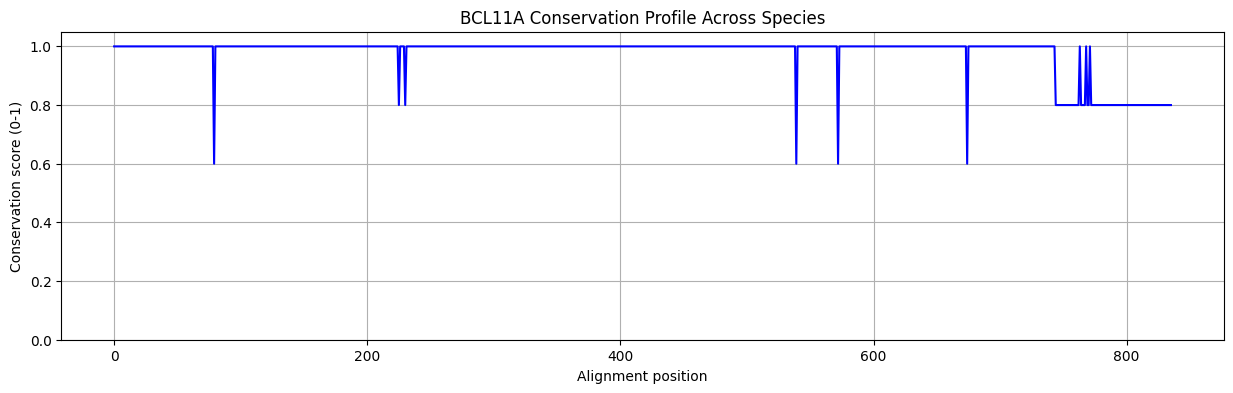

                NP_060484.2  XP_009440776.1  XP_018877105.1  NP_001178612.1  \
NP_060484.2      100.000000       96.761658       96.761658       95.984456   
XP_009440776.1    96.761658      100.000000      100.000000       99.281437   
XP_018877105.1    96.761658      100.000000      100.000000       99.281437   
NP_001178612.1    95.984456       99.281437       99.281437      100.000000   
NP_001229863.1    96.243523       99.520958       99.520958       99.760479   

                NP_001229863.1  
NP_060484.2          96.243523  
XP_009440776.1       99.520958  
XP_018877105.1       99.520958  
NP_001178612.1       99.760479  
NP_001229863.1      100.000000  


In [3]:
from Bio import AlignIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load the Clustal alignment file ---
alignment_file = "BCL11A.aln-clustal_num"
alignment = AlignIO.read(alignment_file, "clustal")  # use "clustal" for .aln files

num_seqs = len(alignment)
alignment_length = alignment.get_alignment_length()
species = [record.id for record in alignment]

print(f"Number of sequences aligned: {num_seqs}")
print(f"Alignment length (columns): {alignment_length}")

# --- Step 2: Per-column conservation score ---
conservation_scores = []
for col_idx in range(alignment_length):
    column = alignment[:, col_idx]
    counts = {}
    for nt in column:
        counts[nt] = counts.get(nt, 0) + 1
    max_count = max(counts.values())
    conservation_scores.append(max_count / num_seqs)

mean_conservation = np.mean(conservation_scores)
fully_conserved_cols = sum(1 for s in conservation_scores if s == 1.0)

print(f"Mean conservation score: {mean_conservation:.3f}")
print(f"Number of fully conserved columns: {fully_conserved_cols}")

# --- Step 3: Plot conservation profile ---
plt.figure(figsize=(15,4))
plt.plot(conservation_scores, color="blue")
plt.xlabel("Alignment position")
plt.ylabel("Conservation score (0-1)")
plt.title("BCL11A Conservation Profile Across Species")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()

# --- Step 4: Sequence similarity matrix ---
identity_matrix = np.zeros((num_seqs, num_seqs))

for i in range(num_seqs):
    for j in range(num_seqs):
        seq_i = alignment[i].seq
        seq_j = alignment[j].seq
        matches = 0
        positions = 0
        for a, b in zip(seq_i, seq_j):
            if a != '-' and b != '-':
                positions += 1
                if a == b:
                    matches += 1
        identity_matrix[i, j] = (matches / positions) * 100 if positions > 0 else 0

identity_df = pd.DataFrame(identity_matrix, index=species, columns=species)
print(identity_df)

# --- Step 5: Save metrics ---
with open("bcl11a_alignment_metrics.txt", "w") as f:
    f.write(f"Number of sequences aligned: {num_seqs}\n")
    f.write(f"Alignment length: {alignment_length}\n")
    f.write(f"Mean conservation score: {mean_conservation:.3f}\n")
    f.write(f"Number of fully conserved columns: {fully_conserved_cols}\n")
    f.write(f"Species: {', '.join(species)}\n")

identity_df.to_csv("bcl11a_identity_matrix.csv")

In [4]:
# =========================
# STEP 6: READ CLUSTAL CONSENSUS LINE
# =========================

with open(alignment_file, "r") as f:
    lines = f.readlines()

# Find consensus line (last line containing * : .)
consensus_line = ""
for line in reversed(lines):
    if "*" in line or ":" in line or "." in line:
        if not line.strip().startswith(alignment[0].id):  # avoid sequence blocks
            consensus_line = line.strip()
            break

# Keep only symbols
consensus_symbols = "".join([c for c in consensus_line if c in "*:."])

num_fully_conserved = consensus_symbols.count("*")
num_conserved_similar = consensus_symbols.count(":")


# =========================
# STEP 7: WHICH SPECIES DIVERGES MOST FROM HUMAN
# =========================

species = [record.id for record in alignment]

# try to detect human sequence
human_index = None
for i, s in enumerate(species):
    if "human" in s.lower() or "homo" in s.lower():
        human_index = i
        break

# fallback: assume first sequence is human if not found
if human_index is None:
    human_index = 0

human_scores = identity_matrix[human_index]
most_divergent_index = np.argmin(
    [human_scores[i] if i != human_index else 100 for i in range(num_seqs)]
)
most_divergent_species = species[most_divergent_index]


# =========================
# STEP 8: MOST CONSERVED REGION (WINDOW ANALYSIS)
# =========================

window_size = 20  # you can change this
window_scores = []

for i in range(alignment_length - window_size):
    window = conservation_scores[i:i+window_size]
    window_scores.append(np.mean(window))

best_region_start = np.argmax(window_scores)
best_region_end = best_region_start + window_size


# =========================
# FINAL OUTPUT TABLE
# =========================

print("\n===== OBSERVATION TABLE =====")
print("Number of sequences aligned:", num_seqs)
print("Total alignment length (columns):", alignment_length)
print("Number of fully conserved positions (*):", num_fully_conserved)
print("Number of conserved but similar positions (:):", num_conserved_similar)
print("Most divergent species from human:", most_divergent_species)
print("Most conserved region:", f"{best_region_start} - {best_region_end}")


# OPTIONAL: SAVE RESULTS
with open("alignment_observations.txt", "w") as f:
    f.write("OBSERVATION TABLE\n")
    f.write(f"Sequences aligned: {num_seqs}\n")
    f.write(f"Alignment length: {alignment_length}\n")
    f.write(f"Fully conserved (*): {num_fully_conserved}\n")
    f.write(f"Conserved similar (:): {num_conserved_similar}\n")
    f.write(f"Most divergent species from human: {most_divergent_species}\n")
    f.write(f"Most conserved region: {best_region_start}-{best_region_end}\n")


===== OBSERVATION TABLE =====
Number of sequences aligned: 5
Total alignment length (columns): 836
Number of fully conserved positions (*): 0
Number of conserved but similar positions (:): 0
Most divergent species from human: NP_001178612.1
Most conserved region: 0 - 20


In [5]:
gap_counts = [(record.id, str(record.seq).count('-')) for record in alignment]

most_gappy = max(gap_counts, key=lambda x: x[1])

print("Species with most gaps:", most_gappy[0])
print("Gap count:", most_gappy[1])

Species with most gaps: NP_060484.2
Gap count: 63


In [6]:
# =========================
# STEP: FIND HUMAN INDEX
# =========================

species = [record.id for record in alignment]

human_index = None
for i, s in enumerate(species):
    if "human" in s.lower() or "homo" in s.lower():
        human_index = i
        break

# fallback if human not clearly labeled
if human_index is None:
    human_index = 0

# =========================
# STEP: GET % ID vs HUMAN
# =========================

human_identity = identity_matrix[human_index]

# exclude self-comparison (100%)
human_identity_clean = [
    (species[i], human_identity[i]) for i in range(len(species)) if i != human_index
]

most_similar = max(human_identity_clean, key=lambda x: x[1])
most_distant = min(human_identity_clean, key=lambda x: x[1])

print("\n===== HUMAN COMPARISON =====")
print("Most similar to human:", most_similar[0], f"({most_similar[1]:.2f}%)")
print("Most distant from human:", most_distant[0], f"({most_distant[1]:.2f}%)")


===== HUMAN COMPARISON =====
Most similar to human: XP_009440776.1 (96.76%)
Most distant from human: NP_001178612.1 (95.98%)


In [7]:
# =========================
# STEP 9: SPECIES WITH MOST GAPS
# =========================

gap_counts = []

for record in alignment:
    seq = str(record.seq)
    gaps = seq.count('-')
    gap_counts.append(gaps)

gap_df = pd.DataFrame({
    "Species": species,
    "Gap_Count": gap_counts
})

# Sort to find worst aligned species
gap_df = gap_df.sort_values(by="Gap_Count", ascending=False)

print("\n===== GAP ANALYSIS =====")
print(gap_df)

most_gappy_species = gap_df.iloc[0]["Species"]
max_gaps = gap_df.iloc[0]["Gap_Count"]

print("\nSpecies with most gaps:")
print(most_gappy_species, "->", max_gaps, "gaps")


===== GAP ANALYSIS =====
          Species  Gap_Count
0     NP_060484.2         63
1  XP_009440776.1          1
2  XP_018877105.1          1
3  NP_001178612.1          1
4  NP_001229863.1          1

Species with most gaps:
NP_060484.2 -> 63 gaps
